In this notebook, we will run a very basic and quick test using YOLO to test if the model can do a good job in just a few epochs. Detailed training will be done later.

In [6]:
# !uv add ultralytics This is problematic, it replaces existing GPU pytorch with CPU pytorch

Imports and configs. Configs seem a little complicated but we use them to be more organised because later on the codebase can be too hard to work on

In [2]:
import sys
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
from ultralytics.utils import SETTINGS
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from helpers.viz import draw_bbox 


DATA_DIR = PROJECT_ROOT / "data"
DATASET_YAML = DATA_DIR / "dataset.yaml"
MODEL_DIR = PROJECT_ROOT / "models" / "yolo26n" # We will use latest yolo model for testing. YOLO 26's nano version is used for this training.
MODEL_PATH = MODEL_DIR / "yolo26n.pt"
BEST_MODEL_PATH = MODEL_DIR / "weights" / "best.pt"
SETTINGS.update(weights_dir=str(MODEL_DIR), runs_dir=str(MODEL_DIR))

In [8]:
torch.cuda.is_available()

True

In [9]:
model = YOLO(str(MODEL_PATH))

Training for 20 epoch on GPU

In [11]:
results = model.train(
    data=str(DATASET_YAML),
    epochs=10,
    imgsz=640,
    save_dir=str(MODEL_DIR),
    exist_ok=True,
)

Ultralytics 8.4.53  Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\Arda\Desktop\Engineering\early-fire-detection\models\yolo26n\yolo26n.pt, momentum=0.937, 

Results of the latest epoch

In [30]:
print(f"Precision: {results.box.mp}")
print(f"Recall: {results.box.mr}")
print(f"mAP@0.5: {results.box.map50}")
print(f"mAP@0.5:95: {results.box.map}")

Precision: 0.8525382913877022
Recall: 0.805691459192724
mAP@0.5: 0.8777616879535579
mAP@0.5:95: 0.5578480577455398


Loading best trained model for testing best model we got throughout training

In [4]:
model = YOLO(str(BEST_MODEL_PATH))

In [23]:
metrics = model.val(
    data=str(DATASET_YAML),
    split="val",
    project=str(MODEL_DIR),
    name="val",
    exist_ok=True,
)

Ultralytics 8.4.53  Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 964.6689.5 MB/s, size: 202.5 KB)
val: Scanning C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\val\labels.cache... 1300 images, 33 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1300/1300  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 13.9it/s 5.9s0.1s
                   all       1300       1580      0.856      0.806      0.879      0.559
                  fire        894        963      0.882       0.86      0.919      0.626
                 smoke        574        617      0.829      0.752      0.838      0.491
Speed: 0.7ms preprocess, 1.6ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\Arda\Desktop\Engineering\early-fire-detection\models\yolo26n\val


In [33]:
print(f"Precision: {results.box.mp}")
print(f"Recall: {results.box.mr}")
print(f"mAP@0.5: {results.box.map50}")
print(f"mAP@0.5:95: {results.box.map}")

for i, name in metrics.names.items(): # Per-class mAP@0.5:0.95 (fire=0, smoke=1)
    print(f"  {name}: {metrics.box.maps[i]}")

Precision: 0.8525382913877022
Recall: 0.805691459192724
mAP@0.5: 0.8777616879535579
mAP@0.5:95: 0.5578480577455398
  fire: 0.6261384579299386
  smoke: 0.4910204257276649


Fire appears easier to detect than smoke. Lets run inference on a sample of test images to see how the model performs.

In [6]:
TEST_IMAGES_DIR = DATA_DIR / "test" / "images"
PREDICT_DIR = MODEL_DIR / "test_predict"

test_images = sorted(TEST_IMAGES_DIR.glob("*.jpg"))


image 1/1 C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\test\images\test_1.jpg: 384x640 1 smoke, 19.3ms
Speed: 2.3ms preprocess, 19.3ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)


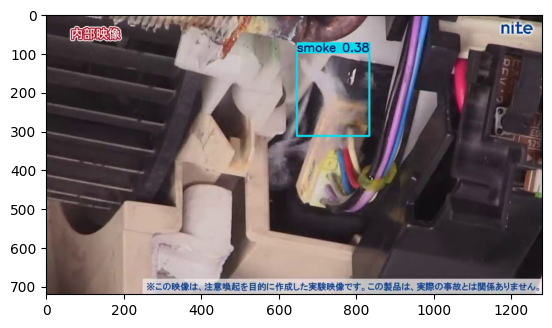

In [50]:
sample_image = test_images[0]
results = model.predict(source=str(sample_image))
annotated_image = results[0].plot()
plt.imshow(annotated_image[:, :, ::-1])
plt.show()

Gave 0.38 confidence for this bbox to be smoke. Lets try on 6 other sample images


image 1/1 C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\test\images\test_1089.jpg: 384x640 2 smokes, 39.9ms
Speed: 1.1ms preprocess, 39.9ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\test\images\test_109.jpg: 384x640 1 fire, 22.5ms
Speed: 0.6ms preprocess, 22.5ms inference, 0.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\test\images\test_1090.jpg: 384x640 1 smoke, 22.5ms
Speed: 0.7ms preprocess, 22.5ms inference, 0.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\test\images\test_1091.jpg: 384x640 (no detections), 24.0ms
Speed: 0.6ms preprocess, 24.0ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\test\images\test_1092.jpg: 384x640 (no detecti

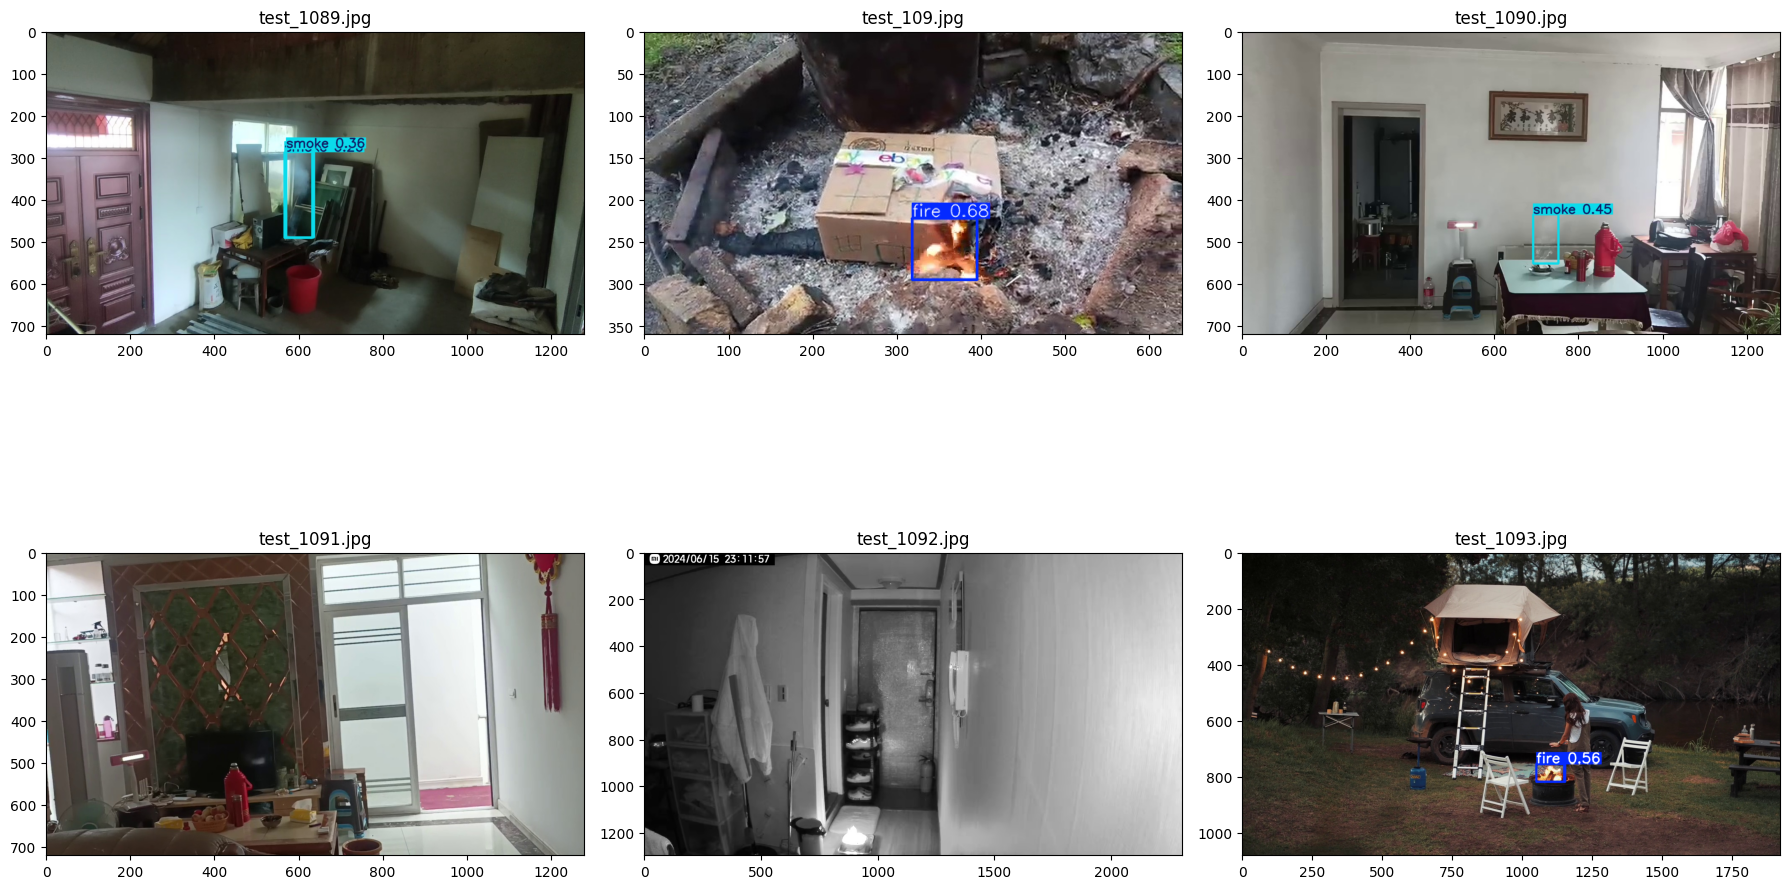

In [ ]:
# Predicted bboxes
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, i in zip(axes.flat, range(100, 106)):
    prediction = model.predict(source=str(test_images[i]))
    result = prediction[0]
    annotated = result.plot()
    ax.imshow(annotated[:, :, ::-1])
    ax.set_title(Path(result.path).name)
plt.tight_layout()
plt.show()

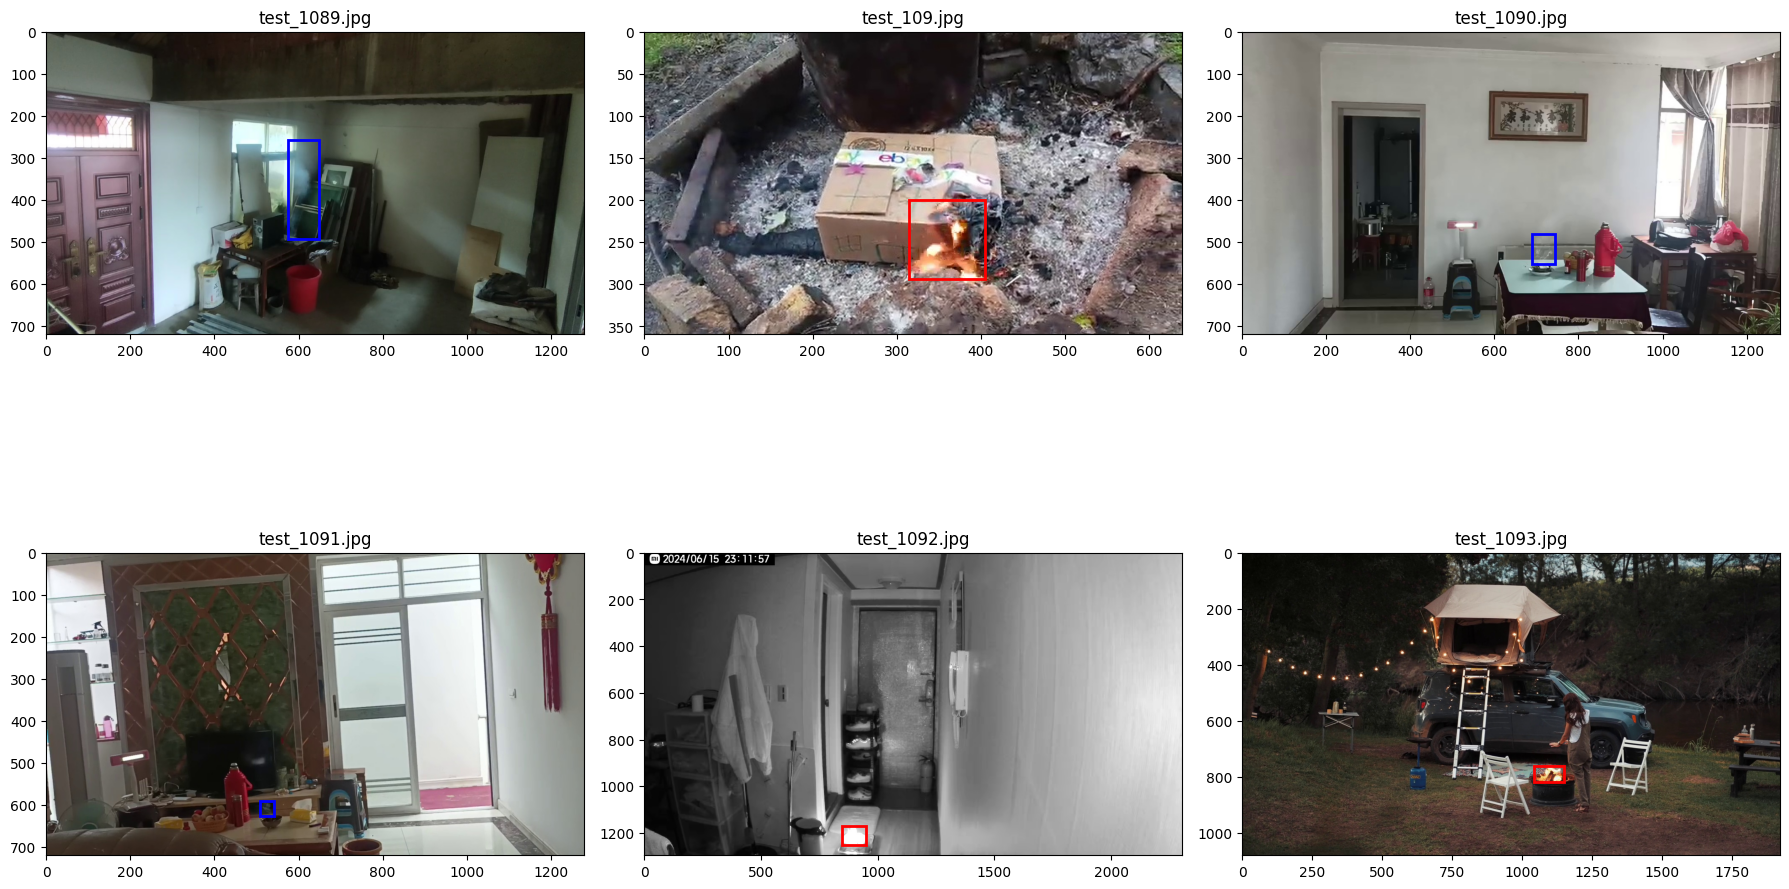

In [ ]:
# Ground truth bboxes
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, i in zip(axes.flat, range(100, 106)):
    img_path = test_images[i]
    label_path = DATA_DIR / "test" / "labels" / f"{img_path.stem}.txt"
    ax.imshow(Image.open(img_path))
    draw_bbox(ax, label_path, img_path)
    ax.set_title(img_path.name)
plt.tight_layout()
plt.show()

#### When we look at these images the model seems to miss some of the critical fire and smoke instances. In this project recall is much more important than precision because detecting a fire early is critical just like in medical screening. So we will mainly look at F2-scores when comparing our results.